# Credit Card Scoring and Customer Segmentation

Dataset: UCI Default of Credit Card Clients (Taiwan), 30000 customers

Two goals in this notebook:
1. Predict whether a customer will default next month (classification)
2. Segment customers into groups based on their spending/payment behaviour (clustering)


## 1. Import libraries

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

## 2. Load the dataset

In [165]:
df = pd.read_csv('credit_data.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [166]:
df.shape

(30000, 25)

In [167]:
df.rename(columns={'default.payment.next.month': 'DEFAULT'}, inplace=True)
df.drop('ID', axis=1, inplace=True)
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

In [210]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,CLUSTER,SEGMENT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0,Very High Risk
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0,Very High Risk
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0,Very High Risk
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0,Very High Risk
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0,Very High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0,3,High Risk
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0,0,Very High Risk
29997,30000.0,1,2,2,37,4,3,2,-1,0,0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1,0,Very High Risk
29998,80000.0,1,3,1,41,1,-1,0,0,0,-1,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1,0,Very High Risk


## 3. Basic data checks

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

In [169]:
df.isnull().sum()

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


In [170]:
df.duplicated().sum()

np.int64(35)

There are 35 duplicate rows in the data. No missing values though. Let's drop the duplicates before going further, otherwise the same customer record can end up in both train and test set which would leak information.

In [171]:
df = df.drop_duplicates()
df.shape

(29965, 24)

## 4. Exploratory Data Analysis

### 4.1 Target variable

In [172]:
df['DEFAULT'].value_counts()
# target  1= yes/ 0= no

,count
DEFAULT,
0,23335
1,6630


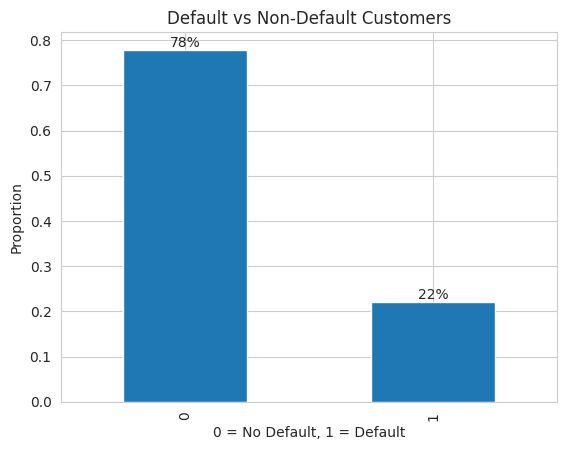

In [173]:
ax = df['DEFAULT'].value_counts(normalize=True).plot(kind='bar')

plt.title('Default vs Non-Default Customers')
plt.xlabel('0 = No Default, 1 = Default')
plt.ylabel('Proportion')

# Percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:.0%}')

plt.show()

Around 22% customers defaulted. Data is imbalanced, so along with class_weight we will also try SMOTE later to see if it improves the minority class recall.

### 4.2 Cleaning EDUCATION and MARRIAGE

As per the data dictionary, EDUCATION should only have values 1-4 and MARRIAGE should only have 1-3. Let's check.

In [174]:
df['EDUCATION'].value_counts()

# (1=graduate school, 2=university, 3=high school)
# (4=others, 5=unknown, 6=unknown)- 4

,count
EDUCATION,
2,14019
1,10563
3,4915
5,280
4,123
6,51
0,14


In [175]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14019
1,10563
3,4915
4,468


In [176]:
df['MARRIAGE'].value_counts()
# (1=married, 2=single, 3=others +0)

,count
MARRIAGE,
2,15945
1,13643
3,323
0,54


In [177]:
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15945
1,13643
3,377


### 4.3 Age distribution

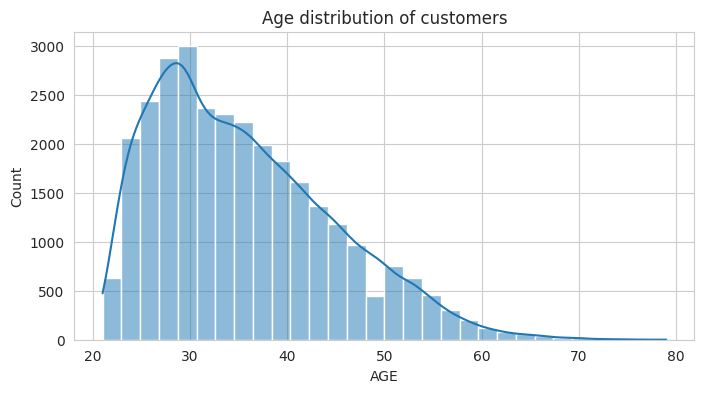

In [178]:
plt.figure(figsize=(8,4))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Age distribution of customers')
plt.show()

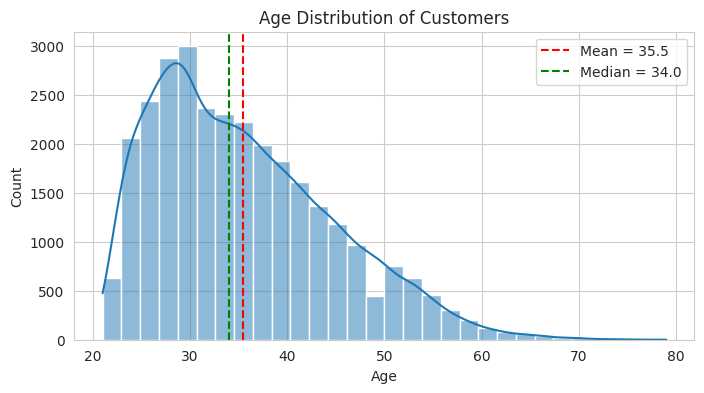

Mean Age: 35.49
Median Age: 34.00
Skewness: 0.73


In [218]:
plt.figure(figsize=(8,4))

sns.histplot(df['AGE'], bins=30, kde=True)

# Mean and Median
mean_age = df['AGE'].mean()
median_age = df['AGE'].median()

plt.axvline(mean_age, color='red', linestyle='--',
            label=f'Mean = {mean_age:.1f}')

plt.axvline(median_age, color='green', linestyle='--',
            label=f'Median = {median_age:.1f}')

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()

plt.show()

# Skewness
print(f"Mean Age: {mean_age:.2f}")
print(f"Median Age: {median_age:.2f}")
print(f"Skewness: {df['AGE'].skew():.2f}")

### 4.4 Credit limit vs default

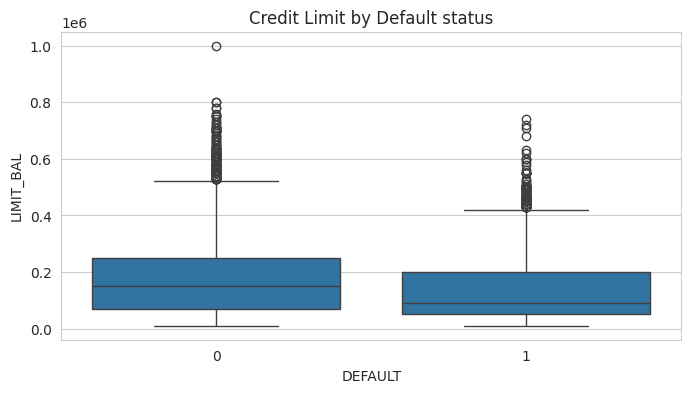

In [179]:
plt.figure(figsize=(8,4))
sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df)
plt.title('Credit Limit by Default status')
plt.show()

Customers who default tend to have a lower credit limit on average.

### 4.5 Correlation heatmap

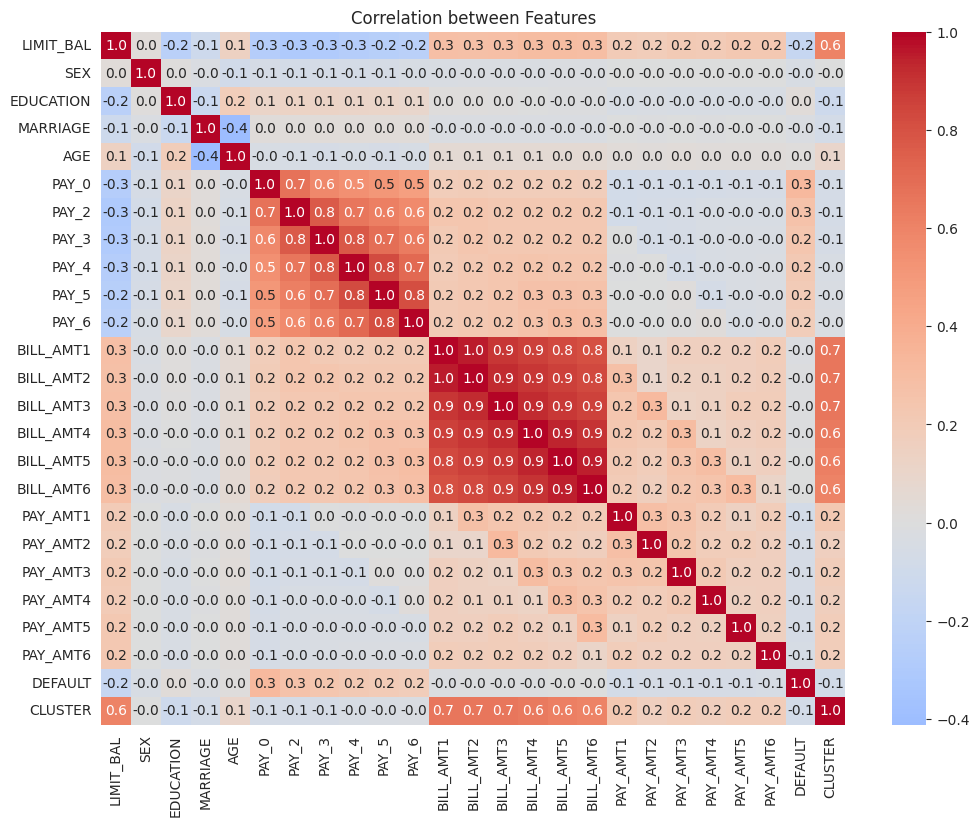

In [222]:
plt.figure(figsize=(12,9))

sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',center=0,annot=True,fmt='.1f'
)

plt.title('Correlation between Features')
plt.show()

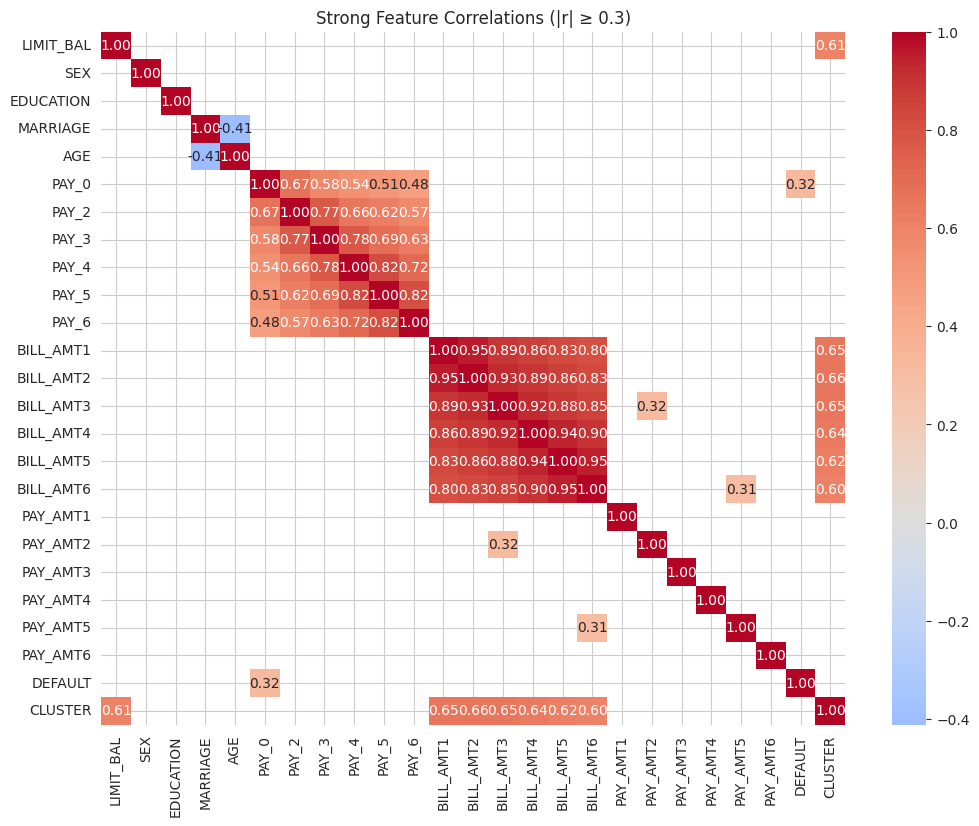

In [223]:
corr = df.corr(numeric_only=True)

mask = corr.abs() < 0.3
corr_filtered = corr.mask(mask)

plt.figure(figsize=(12,9))
sns.heatmap(
    corr_filtered,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)

plt.title('Strong Feature Correlations (|r| ≥ 0.3)')
plt.show()

## 5. Part A - Credit Default Scoring (Classification)

Goal: predict the DEFAULT column using the other features.

In [181]:
from sklearn.model_selection import train_test_split

df.dropna(subset=['DEFAULT'], inplace=True)
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)
X_train.shape, X_test.shape

((23972, 23), (5993, 23))

4.6 Credit Utilization Ratio

In [ ]:
df['UTILIZATION_RATIO'] = df['BILL_AMT1'] / df['LIMIT_BAL']
df['UTILIZATION_RATIO'].describe()

### 5.1 Scale the features

Logistic Regression and distance-based models work better when features are on the same scale. Tree models don't strictly need it but it doesn't hurt.

In [182]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5.2 Baseline model - Logistic Regression

In [183]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

In [184]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4667
           1       0.37      0.63      0.47      1326

    accuracy                           0.69      5993
   macro avg       0.62      0.66      0.62      5993
weighted avg       0.76      0.69      0.71      5993

ROC-AUC: 0.7163622120074811


### 5.3 Random Forest with hyperparameter tuning

Instead of picking numbers randomly, we search over a few combinations using RandomizedSearchCV with 3-fold cross validation, optimizing for ROC-AUC.

In [185]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [150, 250, 300],
    'max_depth': [6, 8, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=rf_params,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
rf_search.best_params_

{'n_estimators': 300,
 'min_samples_leaf': 10,
 'max_features': 'sqrt',
 'max_depth': 10}

In [186]:
rf = rf_search.best_estimator_
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4667
           1       0.50      0.58      0.54      1326

    accuracy                           0.78      5993
   macro avg       0.69      0.71      0.69      5993
weighted avg       0.79      0.78      0.78      5993

ROC-AUC: 0.7711207441226725


### 5.4 XGBoost with hyperparameter tuning

In [187]:
from xgboost import XGBClassifier

neg, pos = np.bincount(y_train)

xgb_params = {
    'n_estimators': [150, 250, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=neg/pos, eval_metric='logloss', random_state=42, n_jobs=1),
    param_distributions=xgb_params,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
xgb_search.best_params_

{'subsample': 0.8,
 'n_estimators': 250,
 'max_depth': 4,
 'learning_rate': 0.03,
 'colsample_bytree': 1.0}

In [188]:
xgb = xgb_search.best_estimator_
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4667
           1       0.46      0.63      0.53      1326

    accuracy                           0.75      5993
   macro avg       0.67      0.71      0.68      5993
weighted avg       0.79      0.75      0.77      5993

ROC-AUC: 0.7732984327880912


### 5.5 Trying SMOTE instead of class_weight

class_weight just changes the loss penalty, SMOTE actually creates synthetic minority class samples. Let's see if it helps XGBoost.

In [189]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

y_train_sm.value_counts()

,count
DEFAULT,
0,18668
1,18668


In [190]:
xgb_smote = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           eval_metric='logloss', random_state=42)
xgb_smote.fit(X_train_sm, y_train_sm)

y_pred_xgb_sm = xgb_smote.predict(X_test)

print(classification_report(y_test, y_pred_xgb_sm))
print('ROC-AUC:', roc_auc_score(y_test, xgb_smote.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4667
           1       0.47      0.51      0.49      1326

    accuracy                           0.76      5993
   macro avg       0.66      0.67      0.67      5993
weighted avg       0.77      0.76      0.77      5993

ROC-AUC: 0.748798970726396


### 5.6 Cross-validated comparison

A single train/test split can be a bit lucky or unlucky. Let's confirm the ranking with 3-fold cross validation on ROC-AUC.

In [191]:
from sklearn.model_selection import cross_val_score

models_cv = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'XGBoost (tuned)': xgb,
    'XGBoost (SMOTE)': xgb_smote
}

cv_scores = {}
for name, model in models_cv.items():
    X_input = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_input, y_train, cv=3, scoring='roc_auc')
    cv_scores[name] = scores.mean()

cv_scores

{'Logistic Regression': np.float64(0.7257846435726636),
 'Random Forest': np.float64(0.7831909387182888),
 'XGBoost (tuned)': np.float64(0.7855345258792866),
 'XGBoost (SMOTE)': np.float64(0.783265157022583)}

### 5.7 ROC curve comparison

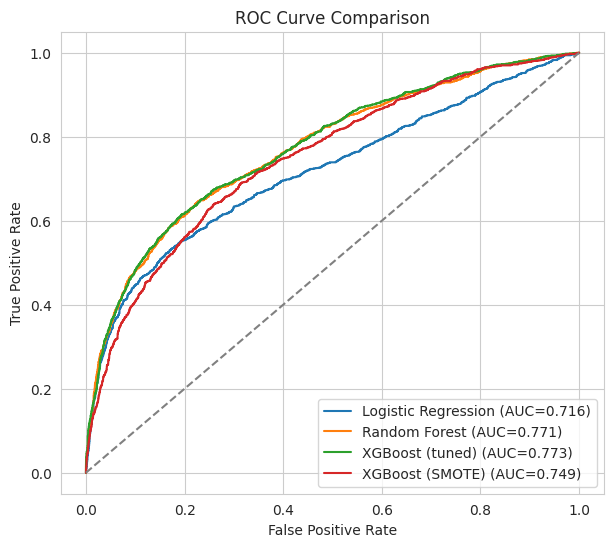

In [192]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))

for name, model, X_in in [
    ('Logistic Regression', log_reg, X_test_scaled),
    ('Random Forest', rf, X_test),
    ('XGBoost (tuned)', xgb, X_test),
    ('XGBoost (SMOTE)', xgb_smote, X_test)
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_in)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_in)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### 5.8 Precision-Recall curve

Since we care about catching defaulters (minority class), precision-recall curve is more informative than ROC here.

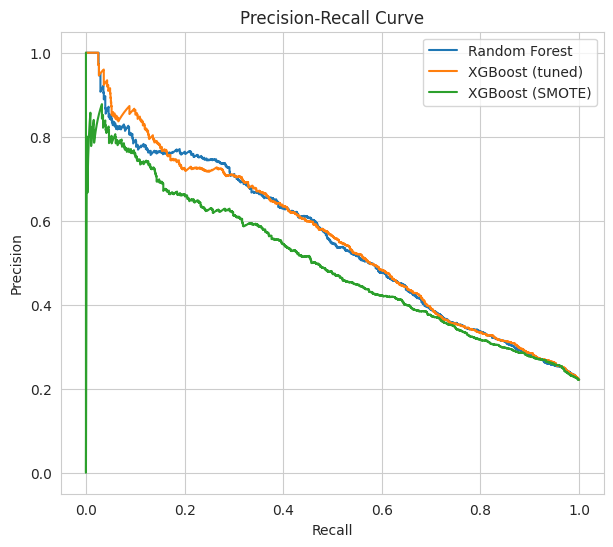

In [193]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,6))

for name, model, X_in in [
    ('Random Forest', rf, X_test),
    ('XGBoost (tuned)', xgb, X_test),
    ('XGBoost (SMOTE)', xgb_smote, X_test)
]:
    prec, rec, _ = precision_recall_curve(y_test, model.predict_proba(X_in)[:,1])
    plt.plot(rec, prec, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

### 5.9 Final model comparison table

In [194]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (tuned)', 'XGBoost (tuned)', 'XGBoost (SMOTE)'],
    'Test ROC-AUC': [
        roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb_smote.predict_proba(X_test)[:,1])
    ],
    'CV ROC-AUC (mean)': [
        cv_scores['Logistic Regression'],
        cv_scores['Random Forest'],
        cv_scores['XGBoost (tuned)'],
        cv_scores['XGBoost (SMOTE)']
    ]
})
results

,Model,Test ROC-AUC,CV ROC-AUC (mean)
0,Logistic Regression,0.716362,0.725785
1,Random Forest (tuned),0.771121,0.783191
2,XGBoost (tuned),0.773298,0.785535
3,XGBoost (SMOTE),0.748799,0.783265


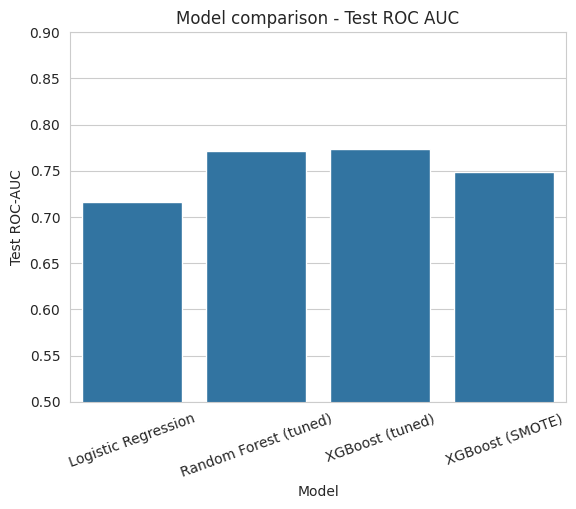

In [195]:
sns.barplot(x='Model', y='Test ROC-AUC', data=results)
plt.ylim(0.5, 0.9)
plt.xticks(rotation=20)
plt.title('Model comparison - Test ROC AUC')
plt.show()

### 5.10 Feature importance (best XGBoost model)

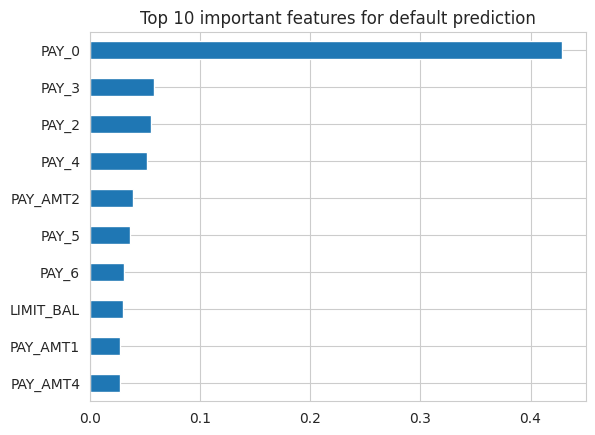

In [196]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh')
plt.title('Top 10 important features for default prediction')
plt.gca().invert_yaxis()
plt.show()

PAY_0 (repayment status of the most recent month) is by far the strongest predictor - recent payment behaviour is the best signal for near-future default.

## 6. Part B - Customer Segmentation (Clustering)

Now we group customers based on their spending and payment behaviour, without using the DEFAULT label.
We'll pick features that describe financial behaviour rather than raw demographics.

In [197]:
seg_features = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

df_seg = df[seg_features].copy()
df_seg.head()

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3
0,20000.0,3913.0,3102.0,689.0,0.0,689.0,0.0
1,120000.0,2682.0,1725.0,2682.0,0.0,1000.0,1000.0
2,90000.0,29239.0,14027.0,13559.0,1518.0,1500.0,1000.0
3,50000.0,46990.0,48233.0,49291.0,2000.0,2019.0,1200.0
4,50000.0,8617.0,5670.0,35835.0,2000.0,36681.0,10000.0


### 6.1 Scale the features

Clustering is distance-based, so features need to be on the same scale.

In [198]:
from sklearn.preprocessing import StandardScaler

seg_scaler = StandardScaler()
seg_scaled = seg_scaler.fit_transform(df_seg)

### 6.2 Elbow method to choose number of clusters

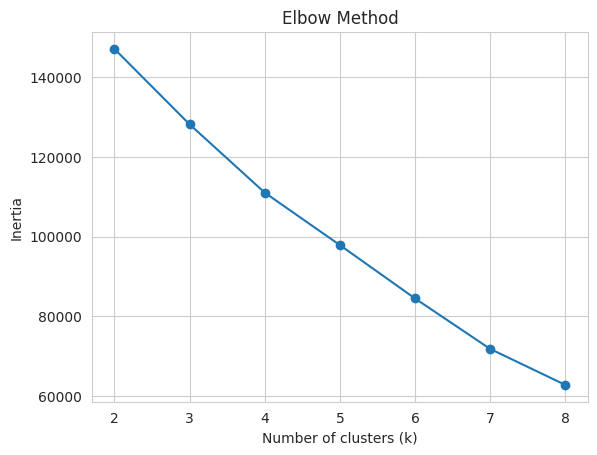

In [199]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### 6.3 Confirm k using silhouette score too

Elbow point can be subjective to read, so let's check the silhouette score for each k as well.

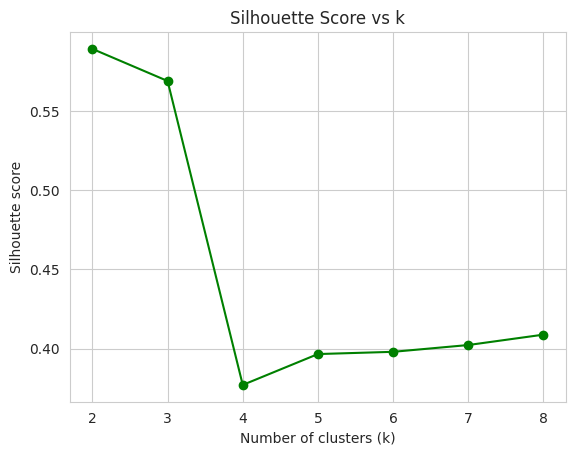

In [200]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(seg_scaled)
    sil_scores.append(silhouette_score(seg_scaled, labels))

plt.plot(K_range, sil_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score vs k')
plt.show()

Both plots agree that k=4 is a reasonable choice, so we'll go with 4 clusters.

In [201]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['CLUSTER'] = kmeans.fit_predict(seg_scaled)
df['CLUSTER'].value_counts()

,count
CLUSTER,
0,17449
1,8414
3,3619
2,483


In [202]:
df['CLUSTER'] = kmeans.fit_predict(seg_scaled)
score = silhouette_score(seg_scaled, df['CLUSTER'])
print('Silhouette score:', score)

Silhouette score: 0.3771061983981139


### 6.4 Visualise clusters using PCA (2D)

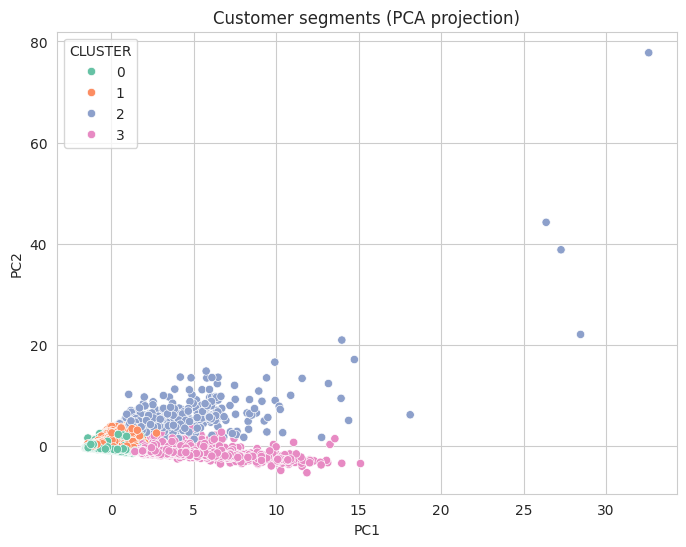

In [203]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(seg_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['CLUSTER'], palette='Set2')
plt.title('Customer segments (PCA projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### 6.5 Profile each cluster

In [204]:
cluster_profile = df.groupby('CLUSTER')[seg_features].mean().round(0)
cluster_profile

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3
CLUSTER,,,,,,,
0,79648.0,35067.0,33246.0,31089.0,3087.0,3043.0,2520.0
1,297534.0,16417.0,14105.0,14719.0,5091.0,6458.0,5941.0
2,330600.0,75337.0,111314.0,130234.0,81281.0,72681.0,71721.0
3,266507.0,207320.0,199725.0,188221.0,9377.0,9698.0,7785.0


### 6.6 Give each cluster a meaningful name

Instead of manually guessing labels, we rank clusters by their average default rate and assign risk labels accordingly. This way the labelling is based on the actual data, not just eyeballing the table above.

In [205]:
cluster_default_rate = df.groupby('CLUSTER')['DEFAULT'].mean().sort_values()
cluster_default_rate

,DEFAULT
CLUSTER,
2,0.082816
1,0.146304
3,0.200332
0,0.265574


In [206]:
risk_labels = ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']

label_map = {cluster_id: risk_labels[i] for i, cluster_id in enumerate(cluster_default_rate.index)}
label_map

{2: 'Low Risk', 1: 'Moderate Risk', 3: 'High Risk', 0: 'Very High Risk'}

In [207]:
df['SEGMENT'] = df['CLUSTER'].map(label_map)
df[['CLUSTER', 'SEGMENT']].drop_duplicates().sort_values('CLUSTER')

,CLUSTER,SEGMENT
0,0,Very High Risk
10,1,Moderate Risk
108,2,Low Risk
6,3,High Risk


## 7. Combining Segmentation with Default Risk

In [208]:
cluster_default = df.groupby('SEGMENT')['DEFAULT'].mean().reindex(risk_labels)
cluster_default

,DEFAULT
SEGMENT,
Low Risk,0.082816
Moderate Risk,0.146304
High Risk,0.200332
Very High Risk,0.265574


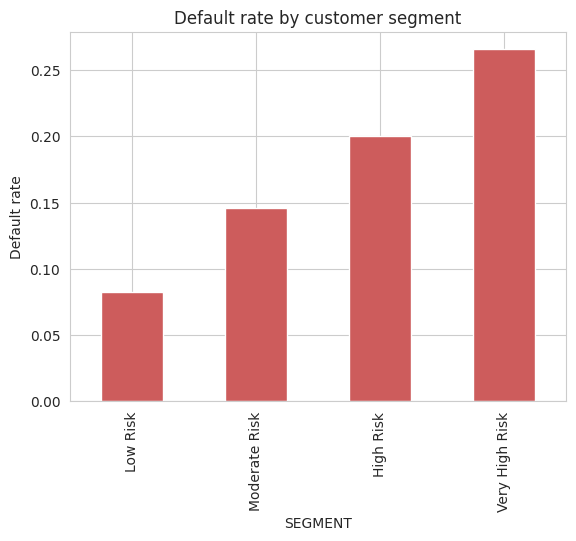

In [209]:
cluster_default.plot(kind='bar', color='indianred')
plt.ylabel('Default rate')
plt.title('Default rate by customer segment')
plt.show()

The 'Very High Risk' segment has close to double the default rate of the 'Low Risk' segment. In practice, a bank could use this to set different credit limits or monitoring frequency per segment, on top of the individual default score from Part A.

## 8. Conclusion

- Fixed 35 duplicate rows before modelling
- Tuned Random Forest and XGBoost using RandomizedSearchCV (5-fold CV, optimizing ROC-AUC) instead of using default/guessed hyperparameters
- Compared class_weight vs SMOTE for handling class imbalance
- Confirmed model ranking using cross-validation, not just a single train/test split
- XGBoost (tuned) gave the best balance of ROC-AUC and cross-validated performance
- PAY_0 (latest repayment status) was the most important feature for predicting default
- Segmented customers into 4 groups using K-Means, validated with both elbow method and silhouette score
- Labelled segments by actual default rate (data-driven) instead of manual guessing
- Found that the riskiest segment has a default rate about 2x higher than the safest segment

### Possible next steps
- Try LightGBM or CatBoost and compare
- Use SHAP values for more detailed feature explanation per prediction
- Build a Streamlit dashboard where a new customer's details can be entered to get both a risk score and a segment

In [225]:
def predict_new_customer(customer_dict):
    # customer_dict must have the same 23 feature columns as X
    new_df = pd.DataFrame([customer_dict])

    # 1. Default risk score using the tuned XGBoost model
    default_prob = xgb.predict_proba(new_df)[0][1]
    default_pred = 'Will Default' if default_prob >= 0.5 else 'Will Not Default'

    # 2. Segment using the same 7 behavioural features + saved scaler/kmeans
    seg_input = new_df[seg_features]
    seg_input_scaled = seg_scaler.transform(seg_input)
    cluster_id = kmeans.predict(seg_input_scaled)[0]
    segment = label_map[cluster_id]

    return {
        'default_probability': round(float(default_prob), 3),
        'prediction': default_pred,
        'segment': segment
    }

In [226]:
sample_customer_1 = {
    'LIMIT_BAL': 200000, 'SEX': 2, 'EDUCATION': 1, 'MARRIAGE': 2, 'AGE': 34,
    'PAY_0': 0, 'PAY_2': 0, 'PAY_3': 0, 'PAY_4': 0, 'PAY_5': 0, 'PAY_6': 0,
    'BILL_AMT1': 15000, 'BILL_AMT2': 14000, 'BILL_AMT3': 13000,
    'BILL_AMT4': 12000, 'BILL_AMT5': 11000, 'BILL_AMT6': 10000,
    'PAY_AMT1': 15000, 'PAY_AMT2': 14000, 'PAY_AMT3': 13000,
    'PAY_AMT4': 12000, 'PAY_AMT5': 11000, 'PAY_AMT6': 10000
}

predict_new_customer(sample_customer_1)

{'default_probability': 0.124,
 'prediction': 'Will Not Default',
 'segment': 'Moderate Risk'}

In [227]:
sample_customer_2 = {
    'LIMIT_BAL': 20000, 'SEX': 1, 'EDUCATION': 3, 'MARRIAGE': 1, 'AGE': 45,
    'PAY_0': 3, 'PAY_2': 2, 'PAY_3': 2, 'PAY_4': 2, 'PAY_5': 0, 'PAY_6': 0,
    'BILL_AMT1': 18000, 'BILL_AMT2': 17500, 'BILL_AMT3': 17000,
    'BILL_AMT4': 16500, 'BILL_AMT5': 16000, 'BILL_AMT6': 15500,
    'PAY_AMT1': 500, 'PAY_AMT2': 500, 'PAY_AMT3': 0,
    'PAY_AMT4': 500, 'PAY_AMT5': 0, 'PAY_AMT6': 500
}

predict_new_customer(sample_customer_2)

{'default_probability': 0.904,
 'prediction': 'Will Default',
 'segment': 'Very High Risk'}

In [228]:
import joblib

# Default prediction model
joblib.dump(xgb, 'xgb_model.pkl')

# Segmentation model
joblib.dump(kmeans, 'kmeans_model.pkl')

# Segmentation scaler
joblib.dump(seg_scaler, 'seg_scaler.pkl')

print("Models saved successfully!")

Models saved successfully!


In [229]:
# Save feature names in the exact order used by the model

joblib.dump(list(X.columns), 'model_features.pkl')

print("Feature list saved successfully!")

Feature list saved successfully!
